In [4]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('fivethirtyeight')

from config import config

In [5]:
df = pd.read_csv(config.paths.path_to_csv)

# Exploratory Data Analysis

## Dataset Overview

### First Observations

In [6]:
df.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


- The dataset contains information about Titanic passengers.
- The target variable is `Survived` (`0` = did not survive, `1` = survived).
- Both numerical (`Age`, `Fare`, `Pclass`) and categorical (`Sex`, `Embarked`, `Cabin`) features are present.
- Missing values are already visible in the first rows, particularly in the `Cabin` feature.
- Further analysis of feature distributions, missing values, and relationships with the target variable is required.

### Data Types

In [7]:
print(df.shape)
print(df.info())

(891, 12)
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB
None


**Key Observations**:

- The dataset contains **891 samples** and **12 features**.
- There are **7 numerical** and **5 categorical** features.
- Missing values are present in `Age`, `Cabin`, and `Embarked`.
- `Cabin` has the highest number of missing values.

### NaNs

In [8]:
df.isna().sum().sort_values(ascending=False)

Cabin          687
Age            177
Embarked         2
PassengerId      0
Name             0
Pclass           0
Survived         0
Sex              0
Parch            0
SibSp            0
Fare             0
Ticket           0
dtype: int64

**Observation:** Missing values are concentrated in `Cabin` and `Age`, whereas all other features are complete. The high proportion of missing values in `Cabin` may affect its usefulness and will require special handling.

### Duplicates

In [9]:
df.duplicated().sum()

np.int64(0)

**Observation:** No duplicate records were found in the dataset.

### Unique values

To better understand the dataset structure, let's examine the number of unique values in each feature. This helps identify binary, categorical, ordinal, and high-cardinality features.

In [10]:
df.nunique()

PassengerId    891
Survived         2
Pclass           3
Name           891
Sex              2
Age             88
SibSp            7
Parch            7
Ticket         681
Fare           248
Cabin          147
Embarked         3
dtype: int64

**Key Observations**:

- `Survived` is a binary target variable.
- `PassengerId` is an identifier feature.
- `Pclass` is an ordinal categorical feature.
- `Name` is an identifier-like high-cardinality feature, but may be useful for extracting titles.
- `Sex` is a binary categorical feature.
- `Age` and `Fare` are continuous numerical features.
- `SibSp` and `Parch` are discrete numerical features.
- `Ticket` and `Cabin` are high-cardinality categorical features.
- `Embarked` is a low-cardinality categorical feature.

### Correlation Matrix

To better understand relationships between features, we build a correlation heatmap. 

In addition to numerical variables, binary categorical features (e.g., `Sex`) can be included by encoding them as numerical values.

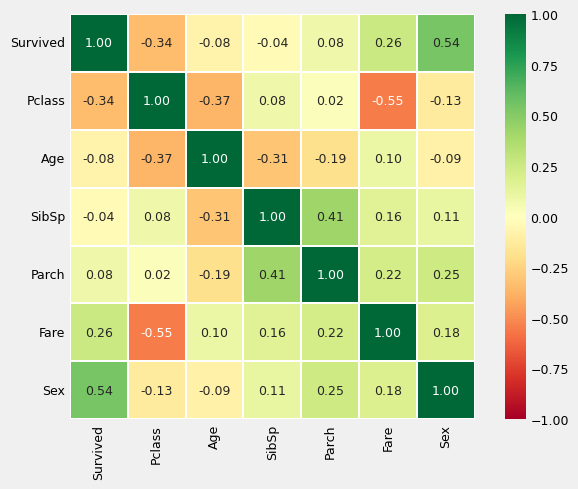

In [11]:
corr_df = df.copy()

# Temporarily encode the binary categorical feature 'Sex' for correlation analysis
corr_df['Sex'] = corr_df['Sex'].map({
    'male': 0,
    'female': 1
})

# Select features for the correlation matrix
corr_matrix = corr_df[
    ['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Sex']
].corr()

# Build a heatmap to visualize linear relationships between selected features
ax = sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    vmin=-1,
    vmax=1,
    cmap='RdYlGn',
    linewidths=0.2,
    annot_kws={"size": 9},
    square=True,
)

# Adjust figure size and font sizes for better readability
fig = plt.gcf()
fig.set_size_inches(7, 5)

plt.xticks(fontsize=9)
plt.yticks(fontsize=9)

# Adjust colorbar font size
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=9)
plt.show()

**Key Observations**:

**Correlation with Survival**

- `Sex` shows the strongest relationship with the target variable (`0.54`). Since `female = 1` and `male = 0`, this indicates that female passengers were significantly more likely to survive.
- `Pclass` has a moderate negative correlation with survival (`-0.34`), suggesting that passengers in higher classes had better survival rates.
- `Fare` exhibits a moderate positive correlation with survival (`0.26`). Passengers who paid higher fares tended to survive more often.

**Relationships Between Features**

- A strong negative correlation is observed between `Pclass` and `Fare` (`-0.55`). This is expected, as passengers in higher classes generally paid higher ticket prices.
- `SibSp` and `Parch` are moderately positively correlated (`0.41`), indicating that passengers traveling with siblings/spouses were also more likely to travel with parents or children.
- `Age` shows a moderate negative correlation with `Pclass` (`-0.37`), suggesting that older passengers tended to travel in higher classes.
- `Sex` has a weak positive correlation with `Parch` (`0.25`), which may indicate that female passengers were more likely to travel with family members.
- `Age` and `SibSp` show a weak negative correlation (`-0.31`), meaning younger passengers were slightly more likely to travel with siblings or spouses.

**Multicollinearity Check**

- No extremely high correlations (e.g., above 0.8–0.9 in absolute value) are observed between the features. Therefore, there is no evidence of severe multicollinearity, and all analyzed features can be retained for further investigation.

### Target analysis

How many people survived?

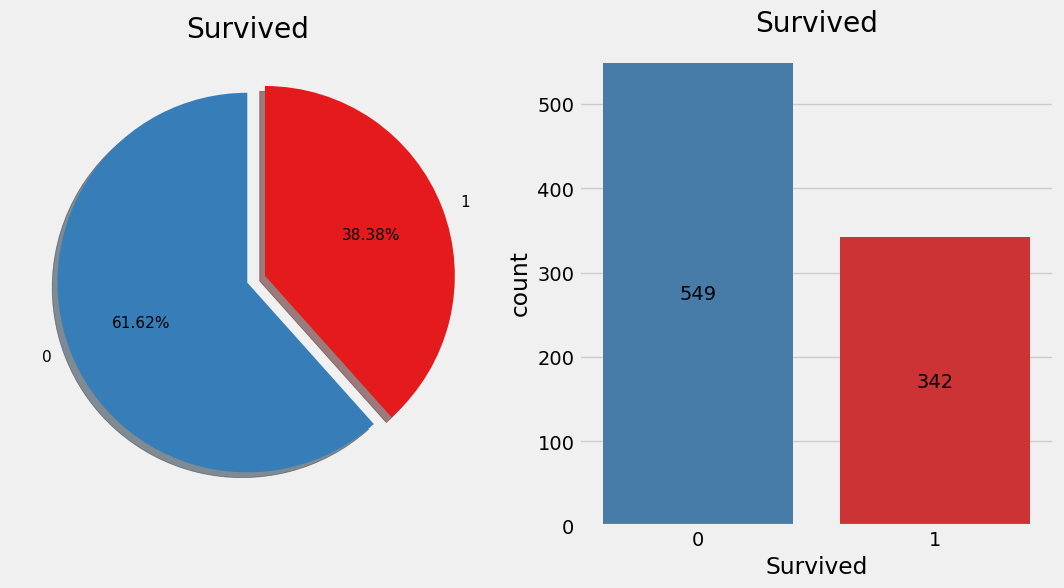

In [12]:
colors = ['#377eb8', '#e41a1c']                             # 0 = blue (not survived), 1 = red (survived)
fig, ax = plt.subplots(1,2, figsize=(12,6))                 # Create a figure with a pie chart and a count plot

df['Survived'].value_counts().plot.pie(
    ax=ax[0],
    autopct='%1.2f%%',
    explode=[0,0.1],
    shadow=True,
    startangle=90,
    textprops={'fontsize':11},
    colors=colors,)
ax[0].set_title("Survived")

sns.countplot(
    x='Survived', 
    data=df, 
    ax=ax[1],
    hue='Survived',
    palette=colors,
    legend=False,)
ax[1].set_title("Survived")

for container in ax[1].containers:                          # Add value labels inside the bars
    ax[1].bar_label(container, label_type='center')
plt.show()

**Observations**:

- Approximately 38.4% of passengers survived (`Survived = 1`), while 61.6% did not survive (`Survived = 0`).
- The target variable is moderately imbalanced, with non-survivors forming the majority class.
- The class imbalance is not severe and is unlikely to require special handling.

### Constant Baseline. Accuracy = 61.62%

Before training any machine learning model, it is useful to establish a simple baseline.

By predicting the majority class (`Survived = 0`) for every passenger, we obtain:

**`Accuracy = 61.62%` = 549/891**

The constant baseline achieves an accuracy of 61.62%. Therefore, any meaningful model should significantly outperform this result.

## Feature Analysis

### Sex → Categorical Feature

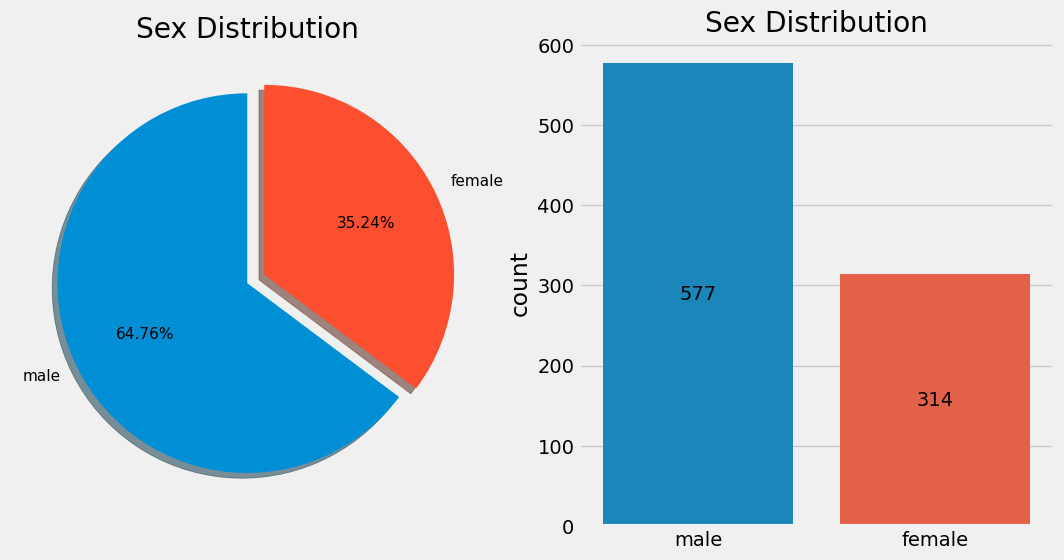

In [13]:
fig, ax = plt.subplots(1,2, figsize=(12,6))                 # Create a figure with a pie chart and a count plot

df['Sex'].value_counts().plot.pie(
    ax=ax[0],
    autopct='%1.2f%%',
    explode=[0,0.1],
    shadow=True,
    startangle=90,
    textprops={'fontsize':11},
    )
ax[0].set_title("Sex Distribution")

sns.countplot(
    x='Sex',
    hue='Sex', 
    data=df, 
    ax=ax[1],
    legend=False,
    )
ax[1].set_title("Sex Distribution")
ax[1].set_xlabel('')

for container in ax[1].containers:                          # Add value labels inside the bars
    ax[1].bar_label(container, label_type='center')
plt.show()

- Male passengers account for approximately 64.8% of the dataset, while female passengers represent 35.2%.
- The dataset contains substantially more male passengers than female passengers.
- `Sex` is an imbalanced categorical feature, with males forming nearly two-thirds of all observations.
- Such a distribution should be considered when analyzing the relationship between `Sex` and the target variable (`Survived`).

In [14]:
df.groupby(['Sex', 'Survived'])['Survived'].count()

Sex     Survived
female  0            81
        1           233
male    0           468
        1           109
Name: Survived, dtype: int64

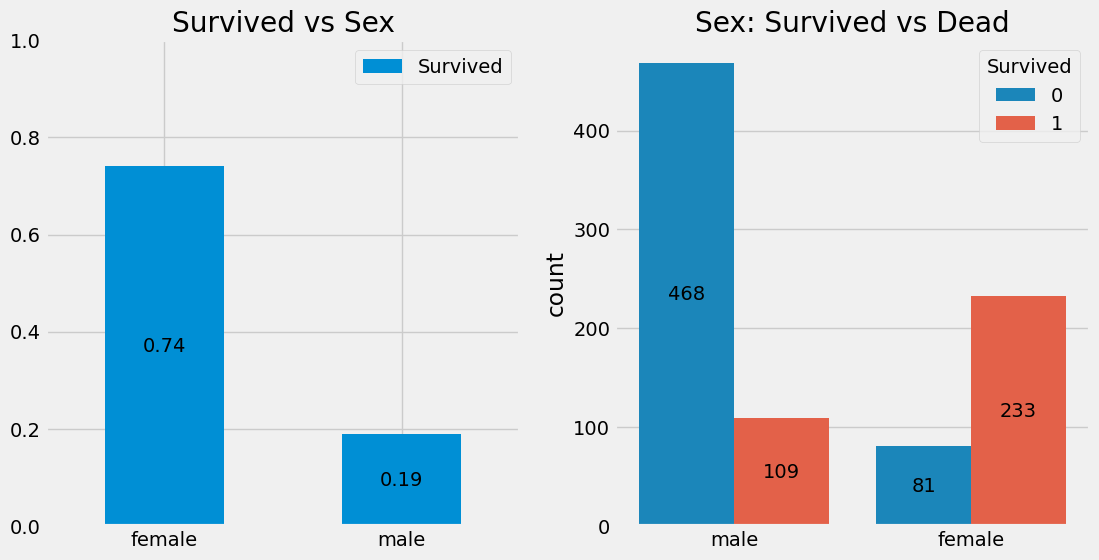

In [15]:
f,ax=plt.subplots(1,2,figsize=(12,6))                       # Create a figure with survival rate and count plots

df[['Sex','Survived']].groupby(['Sex']).mean().plot.bar(
    ax=ax[0],
    ylim=(0, 1),
    rot=0,
)
ax[0].set_title('Survived vs Sex')
ax[0].set_xlabel('')
for container in ax[0].containers:                          # Add value labels inside the bars
    ax[0].bar_label(container, label_type='center', fmt='%.2f')

sns.countplot(x='Sex',hue='Survived',data=df,ax=ax[1])
ax[1].set_title('Sex: Survived vs Dead')
ax[1].set_xlabel('')
for container in ax[1].containers:                          # Add value labels inside the bars
    ax[1].bar_label(container, label_type='center')
plt.show()

**Key Observations**:

- Although male passengers constitute the majority of the dataset, female passengers account for most of the survivors.
- The `survival rate` for **female** passengers is approximately **74%**, compared to only **19%** for **male** passengers.
- A strong relationship between `Sex` and `Survived` is clearly visible.
- `Sex` appears to be one of the most informative features for predicting survival.

### Rule-Based Baseline. Accuracy = 78.68%



Using only the `Sex` feature, we can define a simple rule:

- If `Sex = female` → predict `Survived = 1`
- If `Sex = male` → predict `Survived = 0`

This simple rule achieves:

**`Accuracy = 78.68%` = (468 + 233)/891**

which substantially outperforms the constant baseline:

**Accuracy = 61.62%**

The large improvement over the constant baseline suggests that `Sex` contains substantial predictive information about passenger survival.

### Pclass → Ordinal Feature

Pclass vs Survived

Построим **Cross Table** между признаками **Pclass** и **Survived**.

Для более корректного сравнения используем параметр `normalize='index'`, который позволяет получить долю каждого класса **Survived** внутри каждого значения **Pclass**.

Таким образом, мы сможем оценить влияние пассажирского класса на **Survival Rate**.

In [16]:
pd.crosstab(df.Pclass, df.Survived, margins=True, normalize='index').style.background_gradient(cmap='Greens', vmin=0.1, vmax=0.9).format('{:.1%}')

Survived,0,1
Pclass,,
1,37.0%,63.0%
2,52.7%,47.3%
3,75.8%,24.2%
All,61.6%,38.4%


Key Findings

- The survival rate decreases consistently from 1st Class to 3rd Class: **63% → 47% → 24%**.
- Passengers traveling in 1st Class were more than twice as likely to survive as passengers traveling in 3rd Class.
- A strong relationship between `Pclass` and `Survived` is clearly visible.
- Higher passenger classes were associated with higher survival rates.
- `Pclass` appears to be one of the most informative features for predicting survival.

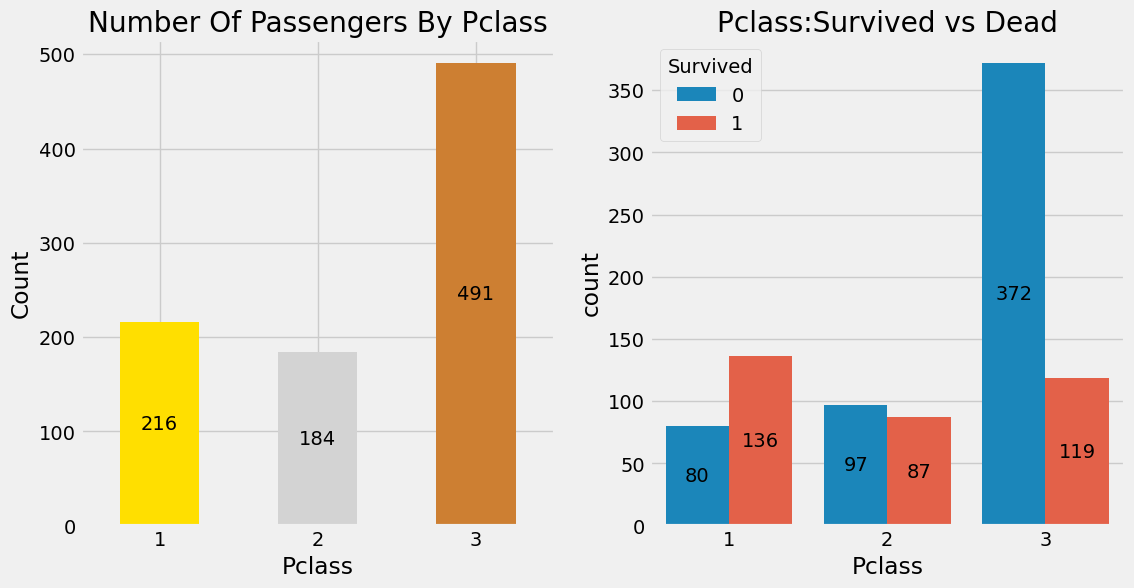

In [17]:
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

df['Pclass'].value_counts().sort_index().plot.bar(
    color=['#FFDF00','#D3D3D3','#CD7F32'],
    ax=ax[0],
    rot=0,
)
ax[0].set_title('Number Of Passengers By Pclass')
ax[0].set_ylabel('Count')
for container in ax[0].containers:                          # Add value labels inside the bars
    ax[0].bar_label(container, label_type='center', fmt='%d')

sns.countplot(
    x='Pclass',
    hue='Survived',
    data=df,
    ax=ax[1],
)
ax[1].set_title('Pclass:Survived vs Dead')
for container in ax[1].containers:                          # Add value labels inside the bars
    ax[1].bar_label(container, label_type='center', fmt='%d')
plt.show()

Key Findings

- More than half of all passengers traveled in 3rd Class (491 passengers).
- 1st Class and 2nd Class contain substantially fewer passengers, with 216 and 184 observations respectively.
- The majority of deaths occurred among 3rd Class passengers.
- The distribution of `Pclass` is uneven, which should be considered during further analysis.
- Together with the previously observed survival rates, these results suggest that `Pclass` contains valuable information about passenger survival.

In [18]:
pd.crosstab(
    [df['Sex'], df['Pclass']],
    df['Survived'],
    normalize='index',
).style.format('{:.1%}').background_gradient(
    cmap='Greens',
)

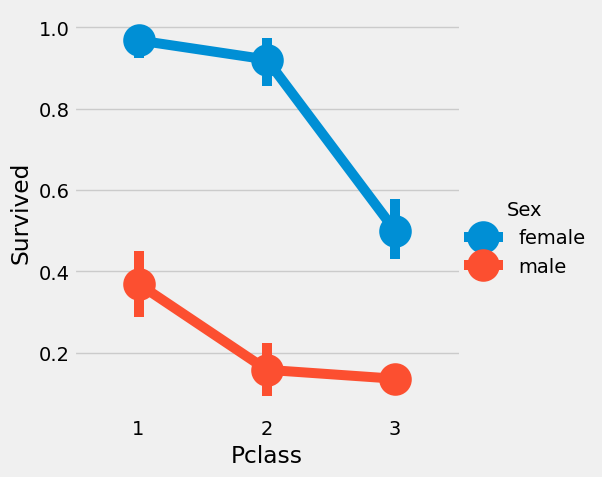

In [19]:
sns.catplot(
    x='Pclass', 
    y='Survived',
    hue='Sex',
    data=df,
    kind='point',
)
plt.show()

Key Findings

- The highest survival rate is observed among female passengers in 1st Class (approximately 97%).
- Female passengers exhibit higher survival rates than male passengers across all passenger classes.
- For female passengers, survival remains high even in 2nd Class (above 90%).
- For male passengers, survival decreases sharply from 1st Class to 2nd and 3rd Class.
- Among male passengers, survival rates in 2nd and 3rd Class are similarly low (around 15%).
- The effect of `Pclass` on survival depends strongly on `Sex`, indicating a potential interaction between these features.

> The effect of `Pclass` on the **Survival Rate** depends on the passenger's `Sex`. This interaction can be leveraged during **Feature Engineering**.

### Age → Continous Feature

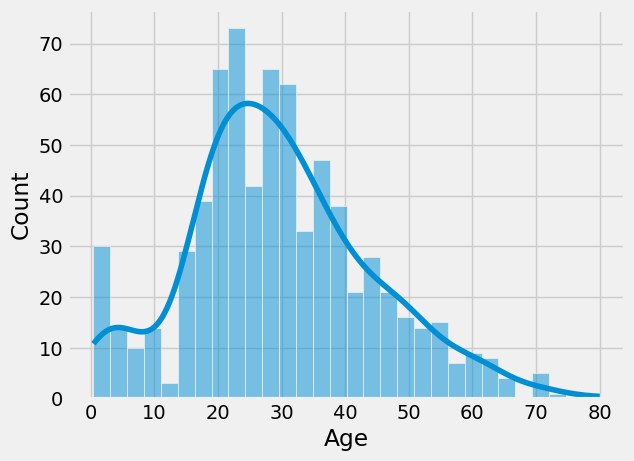

In [20]:
sns.histplot(df['Age'], bins=30, kde=True)
plt.show()

In [21]:
print('Oldest Passenger was of:',df['Age'].max(),'Years')
print('Youngest Passenger was of:',df['Age'].min(),'Years')
print('Average Age on the ship:',round(df['Age'].mean(), 2),'Years')

Oldest Passenger was of: 80.0 Years
Youngest Passenger was of: 0.42 Years
Average Age on the ship: 29.7 Years


About the Plot

- Violin plots show the distribution of **Age** across different values of **Pclass**, **Sex**, and **Survived**.
- Wider sections indicate age ranges with a higher concentration of passengers.
- Dashed lines correspond to the **first quartile (Q1)**, **median (Q2)**, and **third quartile (Q3)**.
- `density_norm='count'` allows the width of the violins to reflect differences in group sizes.
- `cut=0` restricts the violins to the observed age range, so no density is displayed outside the actual data.

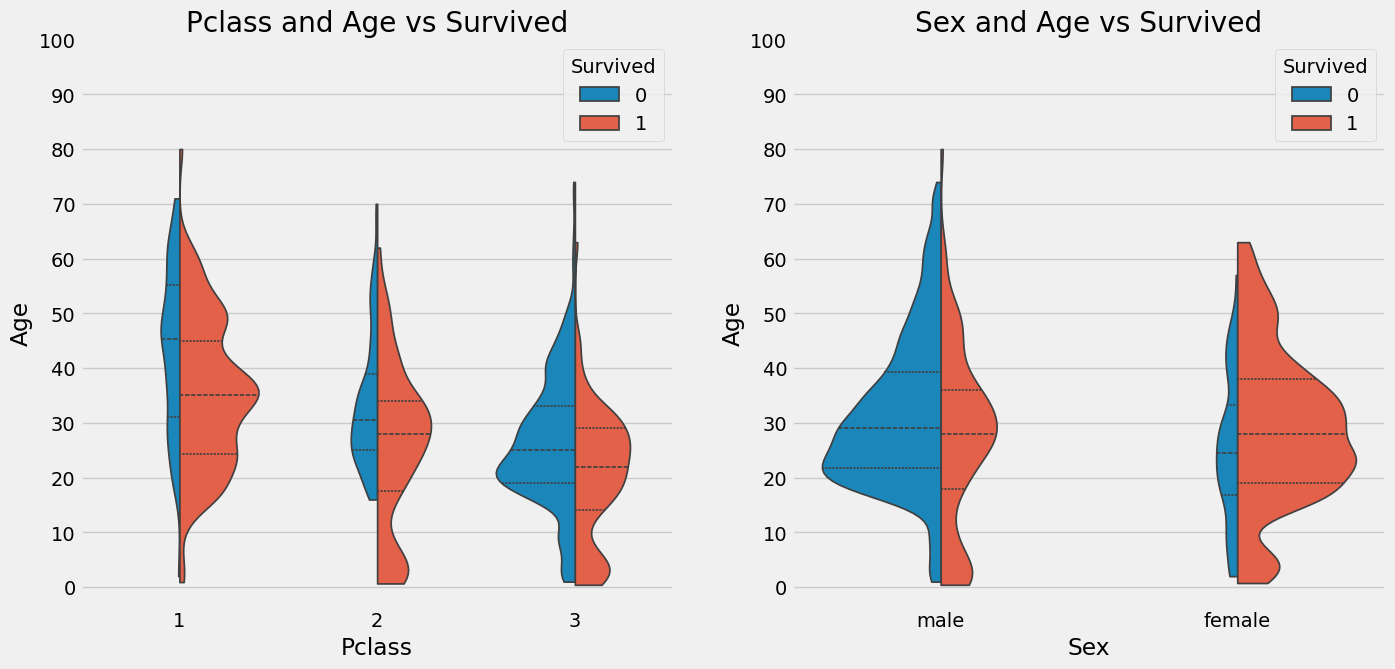

In [22]:
fig, ax = plt.subplots(1, 2, figsize=(15,7))                # Create a figure with two plots

sns.violinplot(
    data=df,
    x='Pclass',
    y='Age',
    hue='Survived',
    split=True,                                         # Split each violin by survival status
    inner='quartile',                                   # Show Q1, median, and Q3
    linewidth=1.25,
    cut=0,                                              # Do not extend beyond observed age values
    density_norm='count',                               # Scale violin width by group size
    # common_norm=True,                                 # Optionally normalize densities across the whole dataset
    ax=ax[0],
    bw_adjust=0.6,                                      # Reduce smoothing to show more detail
)
ax[0].set_title('Pclass and Age vs Survived')
ax[0].set_yticks(range(0,110,10))                           # Set y-axis tick marks

sns.violinplot(
    data=df,
    x='Sex',
    y='Age',
    hue='Survived',
    split=True,                                         # Split each violin by survival status
    inner='quartile',                                   # Show Q1, median, and Q3
    linewidth=1.25,
    cut=0,                                              # Do not extend beyond observed age values
    density_norm='count',                               # Scale violin width by group size
    # common_norm=True,                                 # Optionally normalize densities across the whole dataset
    ax=ax[1],
    bw_adjust=0.6,                                      # Reduce smoothing to show more detail
)
ax[1].set_title('Sex and Age vs Survived')
ax[1].set_yticks(range(0,110,10))                           # Set y-axis tick marks
plt.show()

**Key Findings**

- The distributions support the well-known **"Women and Children First"** evacuation pattern observed during the Titanic disaster.
- Children show noticeably higher survival rates across all passenger classes, especially in **1st** and **2nd Class**, where the age distributions of survivors are clearly shifted toward younger ages.
- In **3rd Class**, the survival rate is substantially lower overall, but younger passengers still appear to have a better chance of survival than adults.
- Female passengers consistently demonstrate higher survival rates than male passengers across almost all age groups.
- The quartile lines suggest that survivors tend to be slightly younger on average than non-survivors, although the difference is moderate rather than dramatic.
- The highest survival probability is observed among **women**, **children**, and passengers traveling in **1st Class**.
- The combination of **Sex**, **Age**, and **Pclass** appears to contain strong predictive information about the target variable **Survived**.

**Feature Engineering Ideas**

The relationship between **Age** and survival is not independent. Survival probability appears to depend on both **Sex** and **Pclass**, suggesting that interaction features such as:

- `Sex × Pclass`
- `Age × Pclass`
- `Age × Sex`

may be useful candidates for future **Feature Engineering**.

Age Imputation Using Passenger Titles

The `Age` feature contains a significant number of missing values. Since passenger age is related to survival probability, replacing missing values with a single global mean or median may distort the data.

To make the imputation more meaningful, passenger titles were extracted from the `Name` feature and grouped into broader categories: `Mr`, `Mrs`, `Miss`, `Master`, and `Other`.

The missing `Age` values will be filled using the median age within each title group. This approach helps preserve differences between children, adult men, adult women, and passengers with rare social or professional titles.

Первоначальное распределение

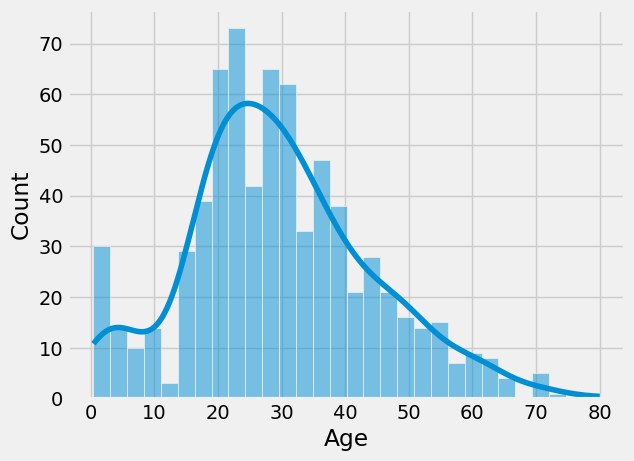

In [23]:
sns.histplot(df['Age'], bins=30, kde=True)
plt.show()

- Возраст имеет правостороннюю асимметрию.
- Основная масса пассажиров находится в диапазоне 20–40 лет.
- Присутствует отдельная группа детей младше 10 лет.

Посмотрим подробнее распледеление категории Дети

<Axes: xlabel='Age', ylabel='Count'>

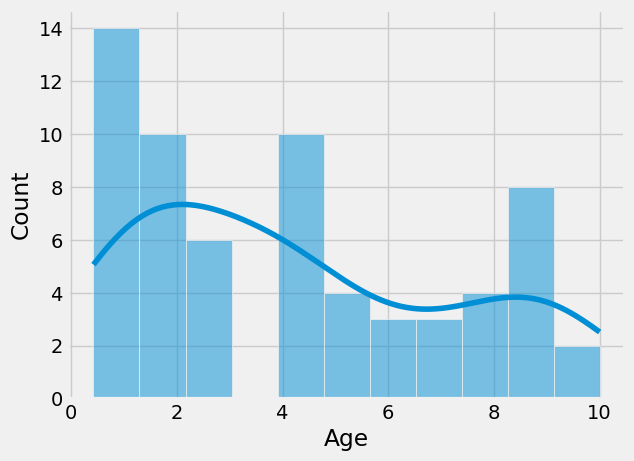

In [24]:
sns.histplot(
    df[(df['Age'] < 11)]['Age'],
    bins=11,
    kde=True,
)

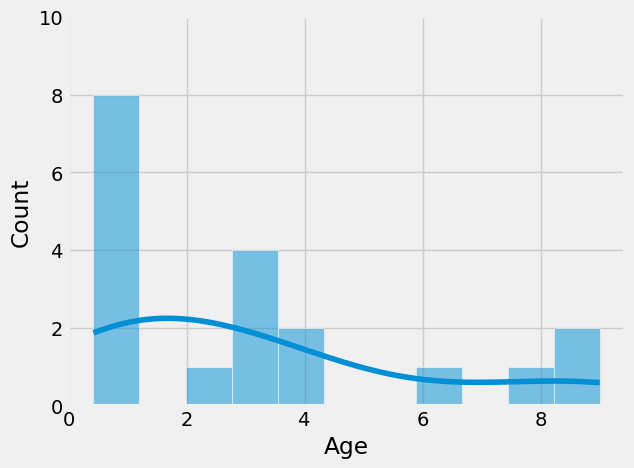

In [25]:
sns.histplot(
    df[(df['Age'] < 11) & (df['Survived'] == 1) & (df['Sex'] == 'male')]['Age'],
    bins=11,
    kde=True,
)
plt.ylim(0, 10)
plt.show()

Выживаемость детей высокая до 5 лет. Такой порог и выберем

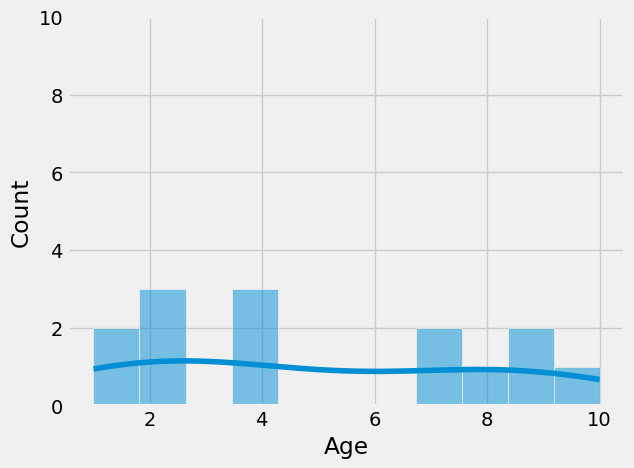

In [26]:
sns.histplot(
    df[(df['Age'] < 11) & (df['Survived'] == 0) & (df['Sex'] == 'male')]['Age'],
    bins=11,
    kde=True,
)
plt.ylim(0, 10)
plt.show()

In [27]:
df[df['Age'].isna()]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
17,18,1,2,"Williams, Mr. Charles Eugene",male,NaN,0,0,244373,13.0000,NaN,S
19,20,1,3,"Masselmani, Mrs. Fatima",female,NaN,0,0,2649,7.2250,NaN,C
26,27,0,3,"Emir, Mr. Farred Chehab",male,NaN,0,0,2631,7.2250,NaN,C
28,29,1,3,"O'Dwyer, Miss. Ellen ""Nellie""",female,NaN,0,0,330959,7.8792,NaN,Q
...,...,...,...,...,...,...,...,...,...,...,...,...
859,860,0,3,"Razi, Mr. Raihed",male,NaN,0,0,2629,7.2292,NaN,C
863,864,0,3,"Sage, Miss. Dorothy Edith ""Dolly""",female,NaN,8,2,CA. 2343,69.5500,NaN,S
868,869,0,3,"van Melkebeke, Mr. Philemon",male,NaN,0,0,345777,9.5000,NaN,S
878,879,0,3,"Laleff, Mr. Kristo",male,NaN,0,0,349217,7.8958,NaN,S


In [28]:
df['Title'] = df['Name'].str.extract(r'([A-Za-z]+)\.')

In [29]:
pd.crosstab(df.Title,df.Sex).T.style.background_gradient(cmap='summer_r', vmin=0, vmax=1) #Checking the Initials with the Sex

Title,Capt,Col,Countess,Don,Dr,Jonkheer,Lady,Major,Master,Miss,Mlle,Mme,Mr,Mrs,Ms,Rev,Sir
Sex,,,,,,,,,,,,,,,,,
female,0,0,1,0,1,0,1,0,0,182,2,1,0,125,1,0,0
male,1,2,0,1,6,1,0,2,40,0,0,0,517,0,0,6,1


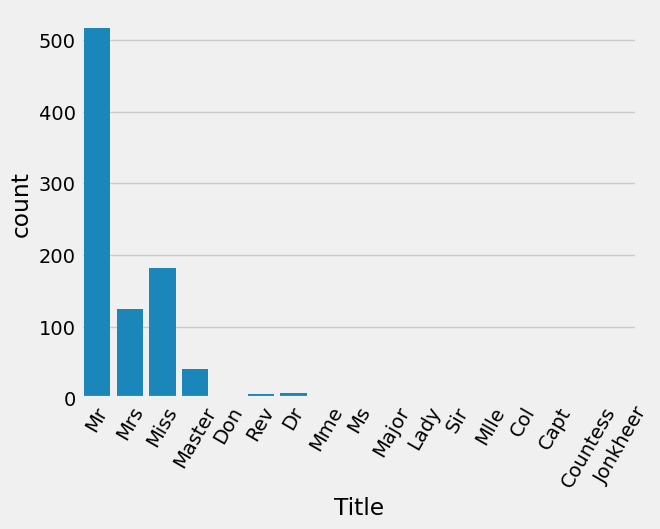

In [30]:
sns.countplot(
    data=df,
    x='Title',
)
plt.xticks(rotation = 60)
plt.show()

In [31]:
title_map = {
    'Mlle': 'Miss',
    'Ms': 'Miss',
    'Mme': 'Mrs',

    'Capt': 'Other',
    'Col': 'Other',
    'Major': 'Other',
    'Countess': 'Other',
    'Don': 'Other',
    'Dr': 'Other',
    'Jonkheer': 'Other',
    'Lady': 'Other',
    'Rev': 'Other',
    'Sir': 'Other'
}

df['Title'] = df['Title'].replace(title_map)

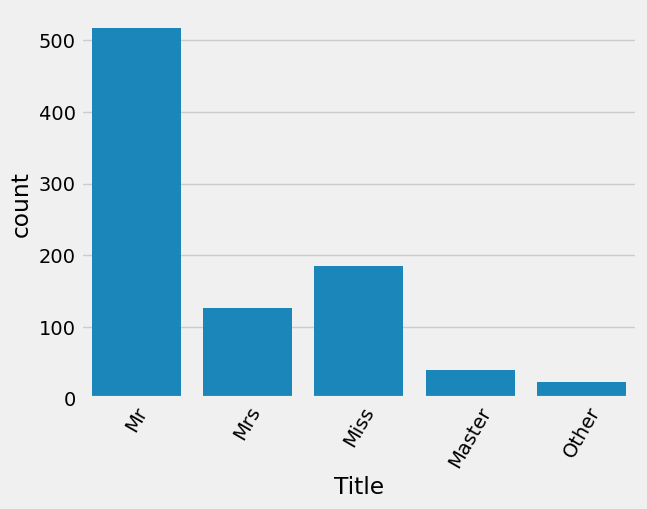

In [32]:
sns.countplot(
    data=df,
    x='Title',
)
plt.xticks(rotation = 60)
plt.show()

In [33]:
df.groupby('Title')['Age'].agg(['count', 'mean', 'median'])

,count,mean,median
Title,,,
Master,36,4.574167,3.5
Miss,149,21.845638,21.0
Mr,398,32.368090,30.0
Mrs,109,35.788991,35.0
Other,22,45.545455,48.5


In [34]:
df_v2 = df[['Age', 'Title']].copy()

In [35]:
df_v2['Age'] = df_v2['Age'].fillna(
    df_v2.groupby('Title')['Age'].transform('median')
)

In [36]:
df_v2['Age'].isna().sum()

np.int64(0)

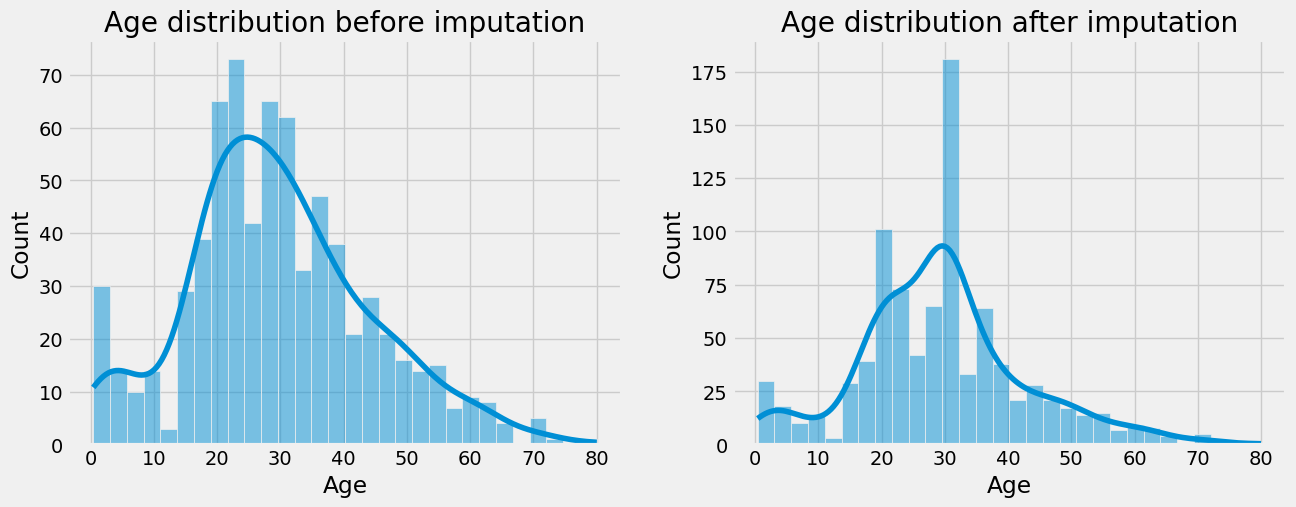

In [37]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['Age'], bins=30, kde=True, ax=ax[0])
ax[0].set_title('Age distribution before imputation')

sns.histplot(df_v2['Age'], bins=30, kde=True, ax=ax[1])
ax[1].set_title('Age distribution after imputation')

plt.show()

The title-based median imputation preserves the relationship between passenger groups and age. However, it introduces visible peaks in the distribution because all missing values within the same title group receive an identical age.

In [38]:
df.groupby('Title')['Age'].agg(['count', 'mean', 'median'])

,count,mean,median
Title,,,
Master,36,4.574167,3.5
Miss,149,21.845638,21.0
Mr,398,32.368090,30.0
Mrs,109,35.788991,35.0
Other,22,45.545455,48.5


In [39]:
df_v2.groupby('Title')['Age'].agg(['count', 'mean', 'median'])

,count,mean,median
Title,,,
Master,40,4.466750,3.5
Miss,185,21.681081,21.0
Mr,517,31.823017,30.0
Mrs,126,35.682540,35.0
Other,23,45.673913,48.5


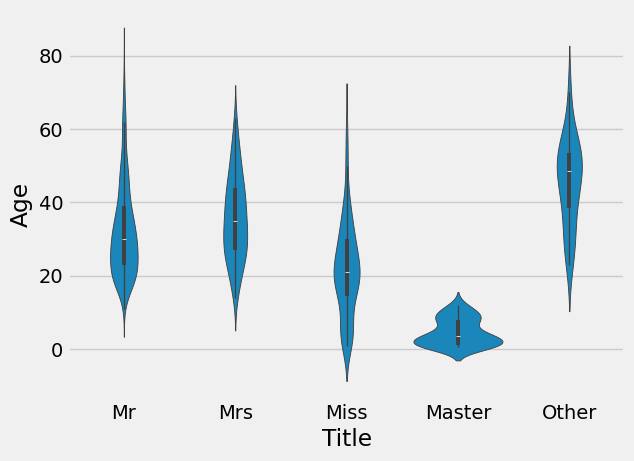

In [40]:
sns.violinplot(
    data=df,
    x='Title',
    y='Age'
)
plt.show()

Relationship Between Title and Age

Before imputing missing values, the relationship between passenger titles and age was examined.

The distributions show clear age differences between title groups:

- `Master` represents young children.
- `Miss` passengers are generally younger than `Mrs`.
- `Mr` and `Mrs` correspond to adult men and women.
- `Other` contains older passengers with rare social or professional titles.

Since age distributions differ substantially across title categories, `Title` provides useful information for estimating missing age values. Therefore, missing values in `Age` will be imputed using the median age within each title group.

### Fare → Continous Feature

In [41]:
df['Fare'].describe()

count    891.000000
mean      32.204208
std       49.693429
min        0.000000
25%        7.910400
50%       14.454200
75%       31.000000
max      512.329200
Name: Fare, dtype: float64

In [42]:
df.sort_values('Fare').head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title
815,816,0,1,"Fry, Mr. Richard",male,NaN,0,0,112058,0.0,B102,S,Mr
806,807,0,1,"Andrews, Mr. Thomas Jr",male,39.0,0,0,112050,0.0,A36,S,Mr
413,414,0,2,"Cunningham, Mr. Alfred Fleming",male,NaN,0,0,239853,0.0,NaN,S,Mr
481,482,0,2,"Frost, Mr. Anthony Wood ""Archie""",male,NaN,0,0,239854,0.0,NaN,S,Mr
302,303,0,3,"Johnson, Mr. William Cahoone Jr",male,19.0,0,0,LINE,0.0,NaN,S,Mr
271,272,1,3,"Tornquist, Mr. William Henry",male,25.0,0,0,LINE,0.0,NaN,S,Mr
277,278,0,2,"Parkes, Mr. Francis ""Frank""",male,NaN,0,0,239853,0.0,NaN,S,Mr
822,823,0,1,"Reuchlin, Jonkheer. John George",male,38.0,0,0,19972,0.0,NaN,S,Other
263,264,0,1,"Harrison, Mr. William",male,40.0,0,0,112059,0.0,B94,S,Mr
466,467,0,2,"Campbell, Mr. William",male,NaN,0,0,239853,0.0,NaN,S,Mr


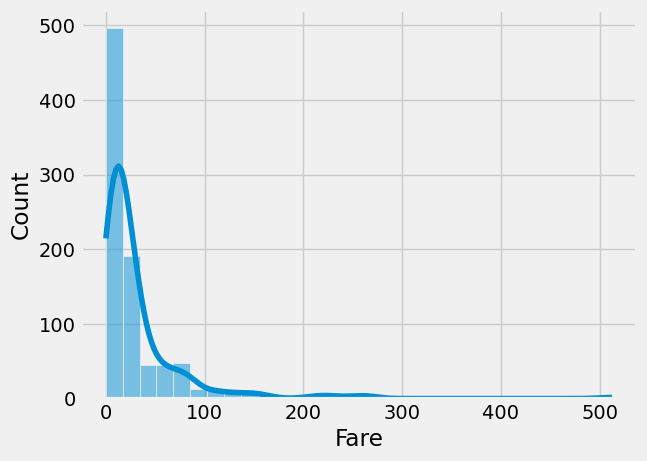

In [43]:
sns.histplot(df['Fare'], bins=30, kde=True)
plt.show()

In [44]:
from sklearn.preprocessing import (
    StandardScaler,
    MinMaxScaler,
    PowerTransformer,
    QuantileTransformer
)

fare = df[['Fare']].copy()

fare_transformed = pd.DataFrame(index=df.index)

# Original
fare_transformed['Fare_original'] = fare['Fare']

# Log transformation
fare_transformed['Fare_log1p'] = np.log1p(fare['Fare'])

# Box-Cox: работает только с положительными значениями, поэтому +1
boxcox = PowerTransformer(method='box-cox', standardize=False)
fare_transformed['Fare_boxcox'] = boxcox.fit_transform(fare[['Fare']] + 1).ravel()

# Yeo-Johnson: работает и с нулями, и с отрицательными значениями
yeo = PowerTransformer(method='yeo-johnson', standardize=False)
fare_transformed['Fare_yeo_johnson'] = yeo.fit_transform(fare[['Fare']]).ravel()

# Quantile Transformer
quantile = QuantileTransformer(
    output_distribution='normal',
    random_state=config.general.seed
)
fare_transformed['Fare_quantile_normal'] = quantile.fit_transform(fare[['Fare']]).ravel()

# MinMaxScaler
minmax = MinMaxScaler()
fare_transformed['Fare_minmax'] = minmax.fit_transform(fare[['Fare']]).ravel()

# StandardScaler
standard = StandardScaler()
fare_transformed['Fare_standard'] = standard.fit_transform(fare[['Fare']]).ravel()

c:\Users\aukha\anaconda3\envs\final_project\Lib\site-packages\sklearn\preprocessing\_data.py:2885: UserWarning: n_quantiles (1000) is greater than the total number of samples (891). n_quantiles is set to n_samples.
  warnings.warn(


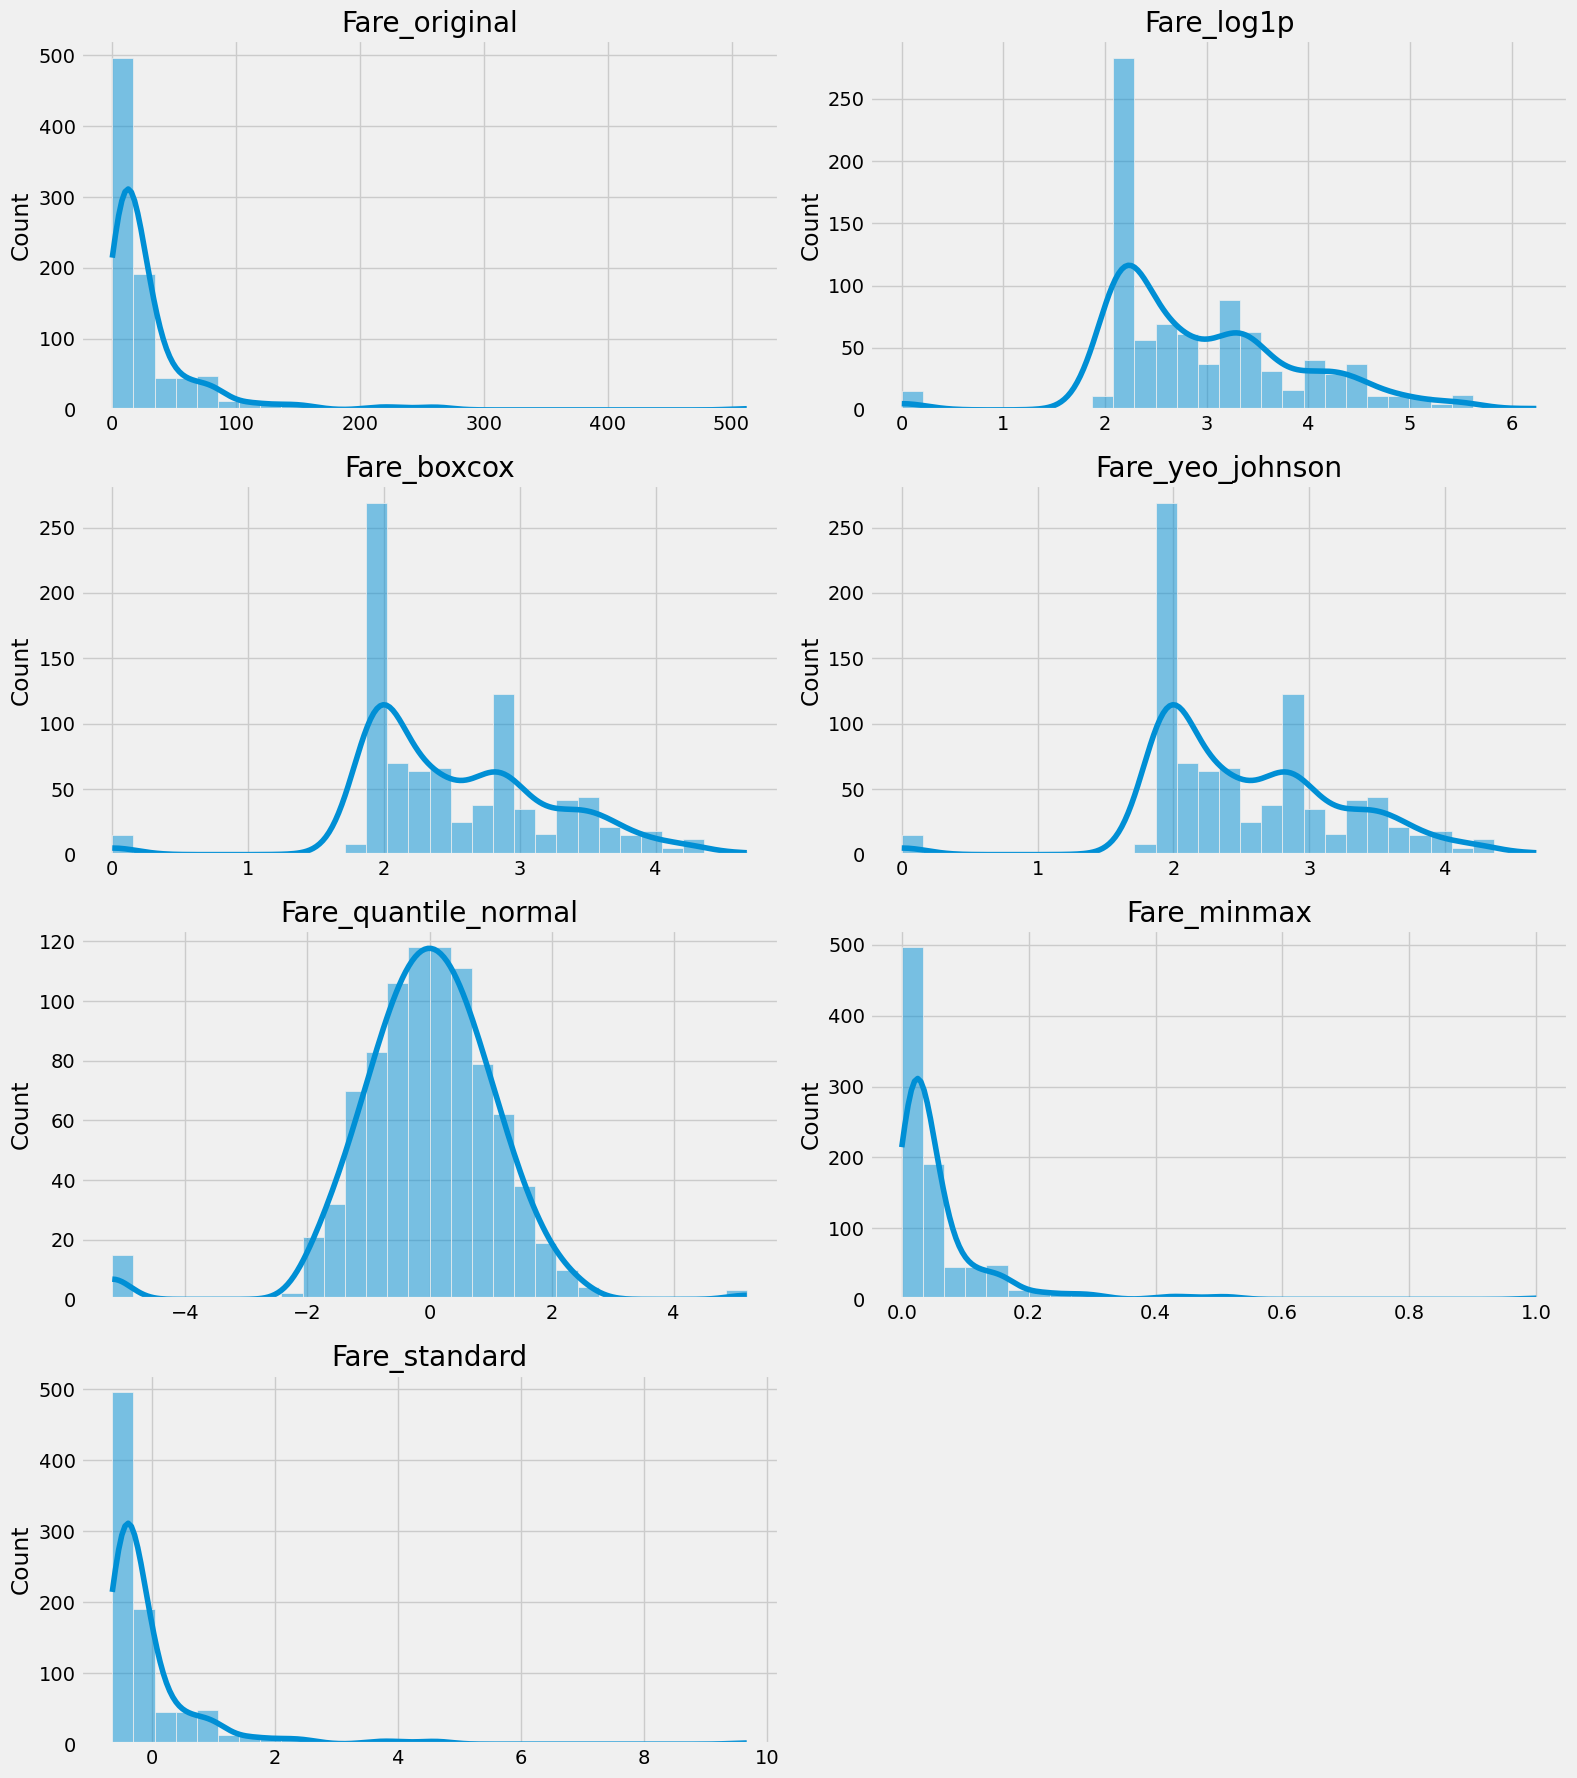

In [45]:
fig, axes = plt.subplots(4, 2, figsize=(16, 18))
axes = axes.ravel()

for i, col in enumerate(fare_transformed.columns):
    sns.histplot(
        fare_transformed[col],
        bins=30,
        kde=True,
        ax=axes[i]
    )
    axes[i].set_title(col)
    axes[i].set_xlabel('')
    
axes[-1].axis('off')

plt.tight_layout()
plt.show()

In [46]:
fare_stats = pd.DataFrame({
    'mean': fare_transformed.mean(),
    'median': fare_transformed.median(),
    'std': fare_transformed.std(),
    'skew': fare_transformed.skew()
}).sort_values('skew', key=abs)

fare_stats

,mean,median,std,skew
Fare_boxcox,2.537799e+00,2.402006,0.718497,-0.040329
Fare_yeo_johnson,2.537799e+00,2.402006,0.718497,-0.040329
Fare_log1p,2.962246e+00,2.737881,0.969048,0.394928
Fare_quantile_normal,-3.909178e-02,-0.005633,1.188240,-0.928213
Fare_original,3.220421e+01,14.454200,49.693429,4.787317
Fare_standard,3.987333e-18,-0.357391,1.000562,4.787317
Fare_minmax,6.285843e-02,0.028213,0.096995,4.787317


### SibSip → Discrete Feature

In [47]:
df['SibSp'].describe()

count    891.000000
mean       0.523008
std        1.102743
min        0.000000
25%        0.000000
50%        0.000000
75%        1.000000
max        8.000000
Name: SibSp, dtype: float64

In [48]:
df.sort_values('SibSp').head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S,Miss
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S,Other
885,886,0,3,"Rice, Mrs. William (Margaret Norton)",female,39.0,0,5,382652,29.1250,NaN,Q,Mrs
884,885,0,3,"Sutehall, Mr. Henry Jr",male,25.0,0,0,SOTON/OQ 392076,7.0500,NaN,S,Mr
883,884,0,2,"Banfield, Mr. Frederick James",male,28.0,0,0,C.A./SOTON 34068,10.5000,NaN,S,Mr
864,865,0,2,"Gill, Mr. John William",male,24.0,0,0,233866,13.0000,NaN,S,Mr
865,866,1,2,"Bystrom, Mrs. (Karolina)",female,42.0,0,0,236852,13.0000,NaN,S,Mrs
867,868,0,1,"Roebling, Mr. Washington Augustus II",male,31.0,0,0,PC 17590,50.4958,A24,S,Mr
868,869,0,3,"van Melkebeke, Mr. Philemon",male,NaN,0,0,345777,9.5000,NaN,S,Mr
870,871,0,3,"Balkic, Mr. Cerin",male,26.0,0,0,349248,7.8958,NaN,S,Mr


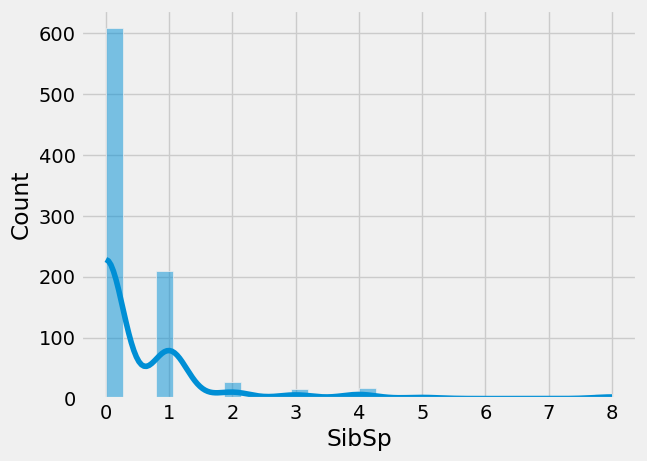

In [49]:
sns.histplot(df['SibSp'], bins=30, kde=True)
plt.show()

In [50]:
pd.crosstab([df.SibSp],df.Survived).style.background_gradient(cmap='summer_r')

Survived,0,1
SibSp,,
0,398,210
1,97,112
2,15,13
3,12,4
4,15,3
5,5,0
8,7,0


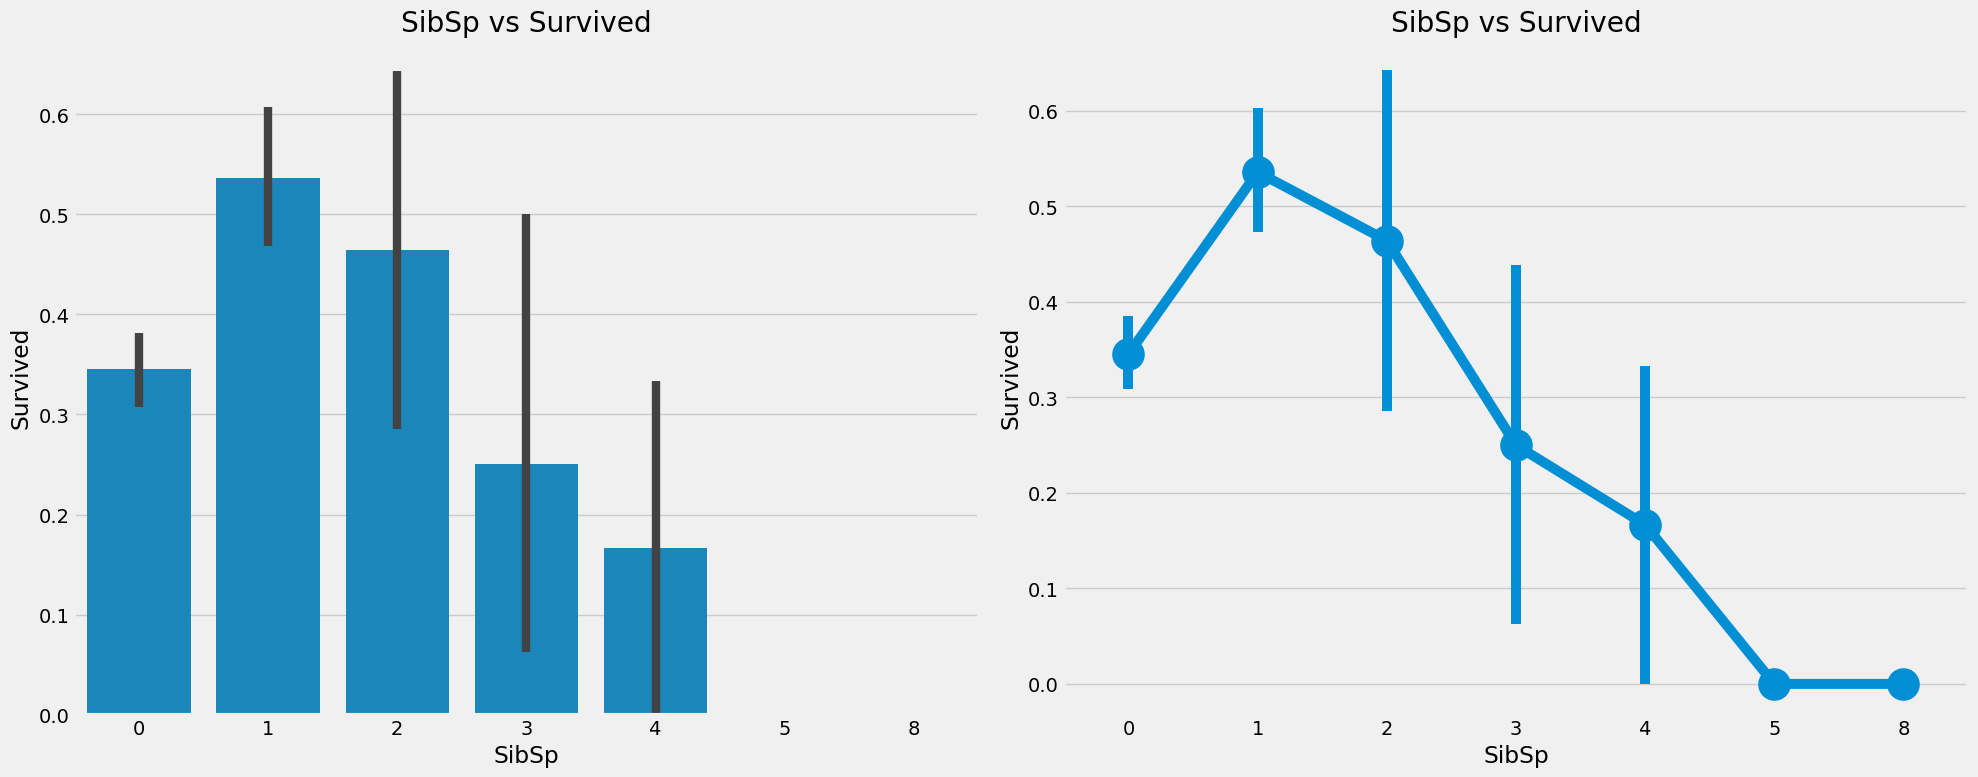

In [51]:
fig, ax = plt.subplots(1, 2, figsize=(20, 8))

sns.barplot(
    x='SibSp',
    y='Survived',
    data=df,
    ax=ax[0]
)
ax[0].set_title('SibSp vs Survived')

sns.pointplot(
    x='SibSp',
    y='Survived',
    data=df,
    ax=ax[1]
)
ax[1].set_title('SibSp vs Survived')

plt.tight_layout()
plt.show()

In [52]:
pd.crosstab(df.SibSp,df.Pclass).style.background_gradient(cmap='summer_r')

Pclass,1,2,3
SibSp,,,
0,137,120,351
1,71,55,83
2,5,8,15
3,3,1,12
4,0,0,18
5,0,0,5
8,0,0,7


### Parch → Discrete Feature

In [53]:
pd.crosstab(df.Parch,df.Pclass).style.background_gradient(cmap='summer_r')

Pclass,1,2,3
Parch,,,
0,163,134,381
1,31,32,55
2,21,16,43
3,0,2,3
4,1,0,3
5,0,0,5
6,0,0,1


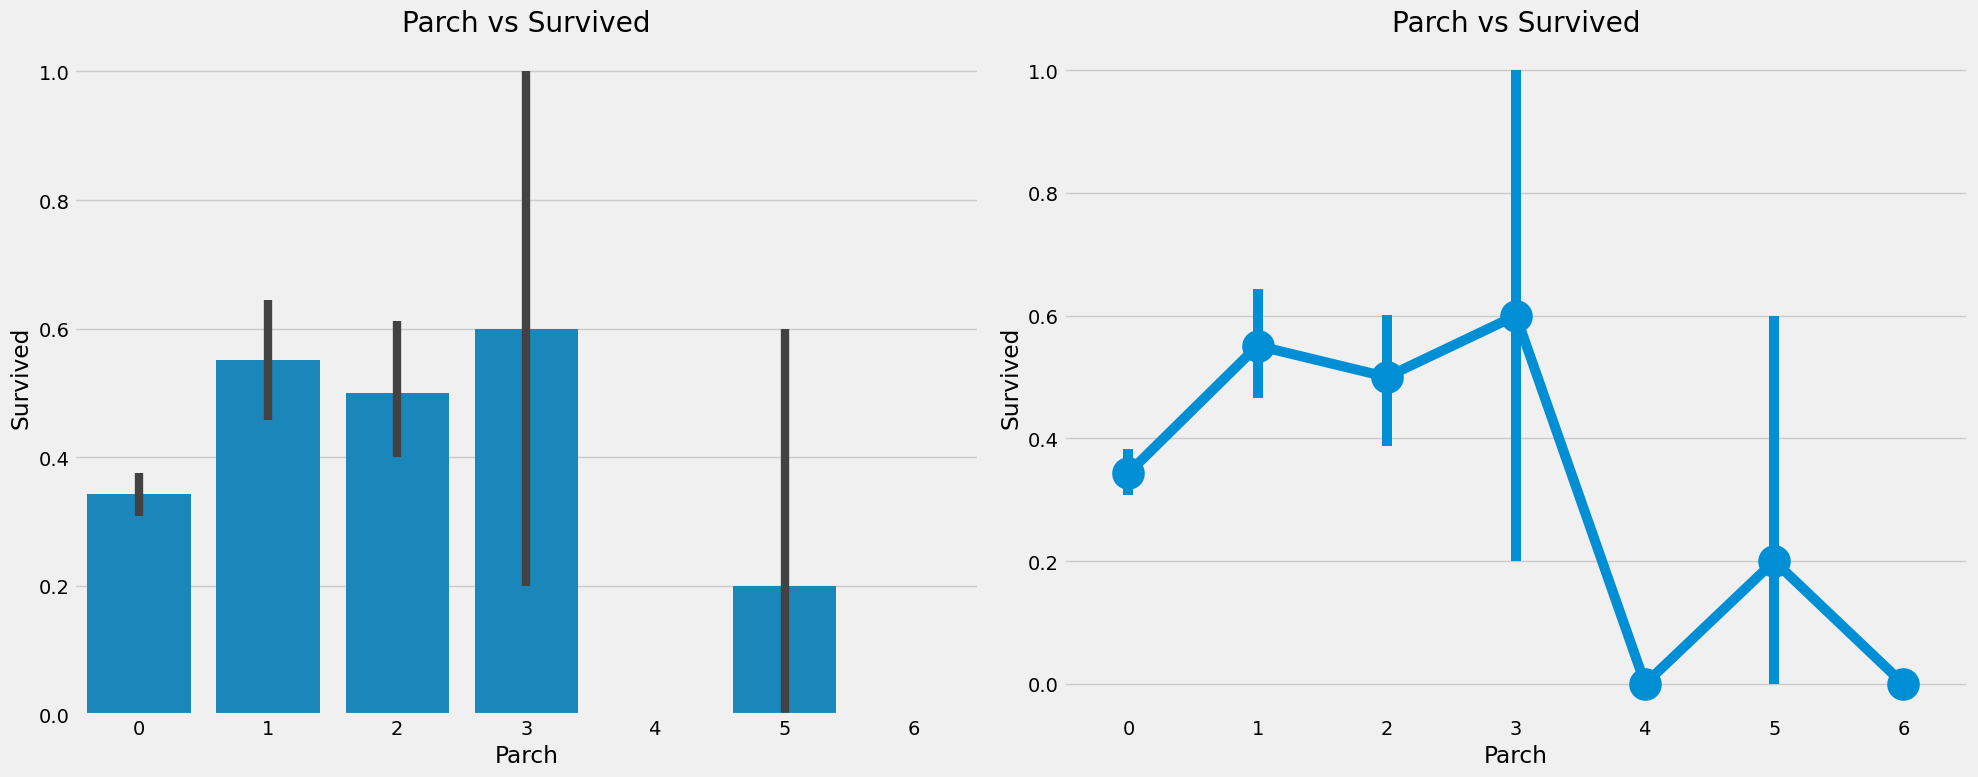

In [54]:
fig, ax = plt.subplots(1, 2, figsize=(20, 8))

sns.barplot(
    x='Parch',
    y='Survived',
    data=df,
    ax=ax[0]
)
ax[0].set_title('Parch vs Survived')

sns.pointplot(
    x='Parch',
    y='Survived',
    data=df,
    ax=ax[1]
)
ax[1].set_title('Parch vs Survived')

plt.tight_layout()
plt.show()

### Embarked -> Categorical Feature

In [55]:
df['Embarked'].describe()

count     889
unique      3
top         S
freq      644
Name: Embarked, dtype: object

In [56]:
df.sort_values('Embarked').head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title
258,259,1,1,"Ward, Miss. Anna",female,35.00,0,0,PC 17755,512.3292,NaN,C,Miss
125,126,1,3,"Nicola-Yarred, Master. Elias",male,12.00,1,0,2651,11.2417,NaN,C,Master
354,355,0,3,"Yousif, Mr. Wazli",male,NaN,0,0,2647,7.2250,NaN,C,Mr
352,353,0,3,"Elias, Mr. Tannous",male,15.00,1,1,2695,7.2292,NaN,C,Mr
128,129,1,3,"Peter, Miss. Anna",female,NaN,1,1,2668,22.3583,F E69,C,Miss
641,642,1,1,"Sagesser, Mlle. Emma",female,24.00,0,0,PC 17477,69.3000,B35,C,Miss
130,131,0,3,"Drazenoic, Mr. Jozef",male,33.00,0,0,349241,7.8958,NaN,C,Mr
798,799,0,3,"Ibrahim Shawah, Mr. Yousseff",male,30.00,0,0,2685,7.2292,NaN,C,Mr
644,645,1,3,"Baclini, Miss. Eugenie",female,0.75,2,1,2666,19.2583,NaN,C,Miss
645,646,1,1,"Harper, Mr. Henry Sleeper",male,48.00,1,0,PC 17572,76.7292,D33,C,Mr


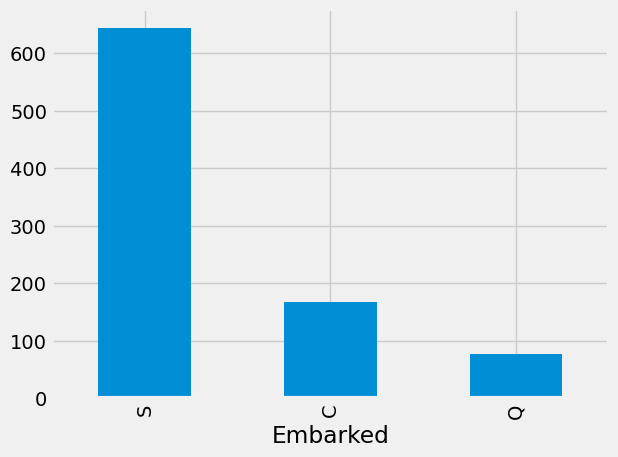

In [57]:
df['Embarked'].value_counts().plot(kind='bar')
plt.show()

In [58]:
pd.crosstab([df.Embarked,df.Pclass],[df.Sex,df.Survived],margins=True).style.background_gradient(cmap='summer_r')

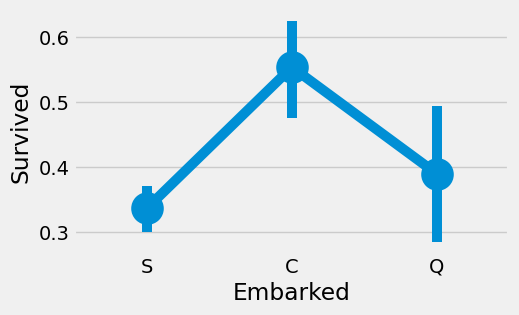

In [59]:
sns.pointplot(x='Embarked',y='Survived',data=df)
fig=plt.gcf()
fig.set_size_inches(5,3)
plt.show()

### Cabin -> High-Cardinality Categorical Feature

In [60]:
df['Cabin'].describe()

count     204
unique    147
top        G6
freq        4
Name: Cabin, dtype: object

In [61]:
df.sort_values('Cabin').head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title
583,584,0,1,"Ross, Mr. John Hugo",male,36.0,0,0,13049,40.1250,A10,C,Mr
475,476,0,1,"Clifford, Mr. George Quincy",male,NaN,0,0,110465,52.0000,A14,S,Mr
556,557,1,1,"Duff Gordon, Lady. (Lucille Christiana Sutherl...",female,48.0,1,0,11755,39.6000,A16,C,Other
284,285,0,1,"Smith, Mr. Richard William",male,NaN,0,0,113056,26.0000,A19,S,Mr
599,600,1,1,"Duff Gordon, Sir. Cosmo Edmund (""Mr Morgan"")",male,49.0,1,0,PC 17485,56.9292,A20,C,Other
630,631,1,1,"Barkworth, Mr. Algernon Henry Wilson",male,80.0,0,0,27042,30.0000,A23,S,Mr
867,868,0,1,"Roebling, Mr. Washington Augustus II",male,31.0,0,0,PC 17590,50.4958,A24,S,Mr
647,648,1,1,"Simonius-Blumer, Col. Oberst Alfons",male,56.0,0,0,13213,35.5000,A26,C,Other
209,210,1,1,"Blank, Mr. Henry",male,40.0,0,0,112277,31.0000,A31,C,Mr
185,186,0,1,"Rood, Mr. Hugh Roscoe",male,NaN,0,0,113767,50.0000,A32,S,Mr


# Preprocessing Experiments

## Age preprocessing experiments

The `Age` feature contains missing values and is one of the most informative numerical features in the Titanic dataset.

This section investigates two questions:

1. Which missing value imputation strategy provides the most informative Age estimates?
2. Does additional distribution transformation improve model performance after imputation?

All experiments were performed inside the sklearn Pipeline to avoid data leakage.

### Missing value imputation

Several strategies were evaluated for filling missing Age values:

- Mean
- Median
- Median Age by passenger Title

The goal is to compare how each strategy changes the distribution of Age and whether it provides more realistic estimates.

In [69]:
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt
import seaborn as sns

In [70]:
age_original = df[['Age']].copy()

age_mean = (
    SimpleImputer(strategy='mean')
    .fit_transform(age_original)
    .ravel()
)

age_median = (
    SimpleImputer(strategy='median')
    .fit_transform(age_original)
    .ravel()
)

In [71]:
from src.feature_engineering import TitleMedianAgeImputer

age_title = TitleMedianAgeImputer()

age_title = (
    age_title
    .fit_transform(df.copy())['Age']
)

In [72]:
age_versions = {
    'Original': age_original['Age'],
    'Mean': age_mean,
    'Median': age_median,
    'Title Median': age_title,
}

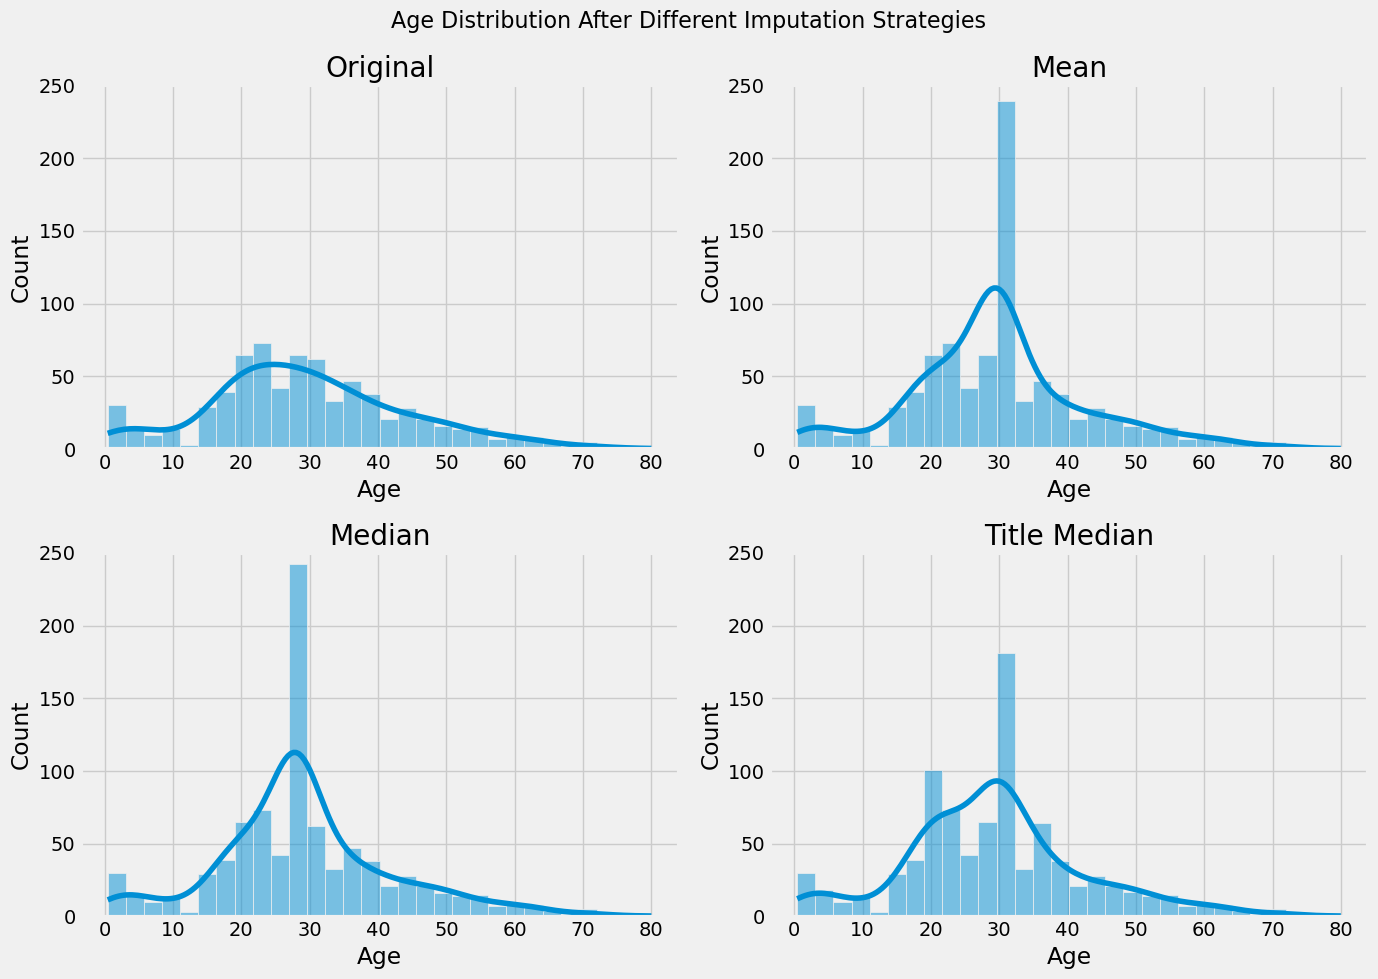

In [84]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes = axes.ravel()

for axis, (name, values) in zip(axes, age_versions.items()):

    sns.histplot(
        values,
        bins=30,
        kde=True,
        ax=axis,
    )

    axis.set_title(name)
    axis.set_xlabel('Age')
    axis.set_ylabel('Count')
    axis.set_ylim(0, 250)

plt.suptitle(
    'Age Distribution After Different Imputation Strategies',
    fontsize=16,
)

plt.tight_layout()

plt.show()

**Observations**

- Mean and Median imputation create a large artificial peak because every missing value is replaced with the same constant.
- Title-based imputation also introduces repeated values, but the peak is noticeably smaller since missing ages are distributed across multiple passenger groups.
- As a result, the overall Age distribution remains closer to the original dataset.
- This produces more realistic age estimates and preserves the relationship between Age and passenger Title.

**Conclusion**

Title-based imputation preserves the natural structure of the Age feature better than global Mean or Median imputation, making it a more informative preprocessing strategy.

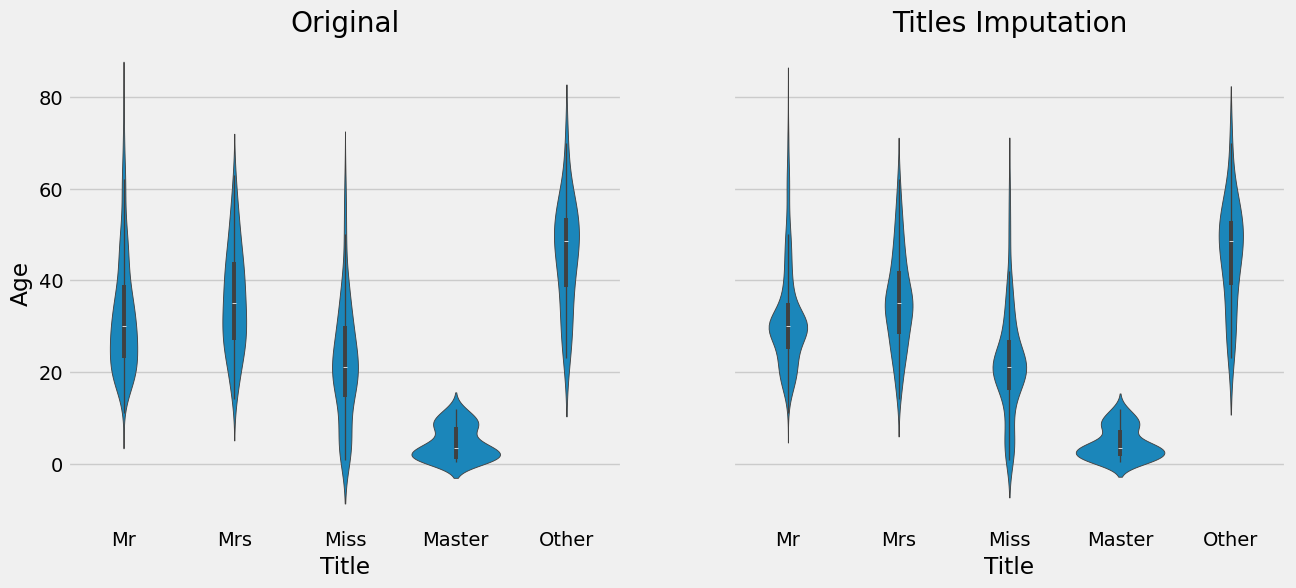

In [79]:
fig, ax = plt.subplots(1,2,figsize=(14, 6),sharey=True,)

sns.violinplot(
    data=df,
    x='Title',
    y='Age',
    ax=ax[0]
)
ax[0].set_title("Original")

filled_df = TitleMedianAgeImputer().fit_transform(df.copy())

sns.violinplot(
    data=filled_df,
    x='Title',
    y='Age',
    ax=ax[1]
)
ax[1].set_title("Titles Imputation")
plt.show()

**Observations**

- Before imputation, each Title group already exhibits a distinct Age distribution.
- `Master` passengers are predominantly young children, while `Mr`, `Mrs`, and `Other` correspond to progressively older groups.
- After Title-based imputation, the missing values are filled with ages that remain consistent with each Title category.
- This prevents unrealistic combinations such as a `Master` passenger receiving the global median age.

**Conclusion**

Title-based imputation preserves the semantic relationship between `Title` and `Age`. As a result, the Age feature becomes more informative, which is reflected in the improvement of Cross Validation and Kaggle Leaderboard performance.
> **Experiment result:** Replacing global median imputation with Title-based median imputation improved Cross Validation Accuracy from **0.8315** to **0.8343** while also increasing the Kaggle Public Leaderboard score from **0.76794** to **0.77272**.

### Distribution transformations

After selecting the best missing value imputation strategy, several distribution transformations were evaluated.

The objective was to determine whether reshaping the Age distribution provides additional information for Logistic Regression beyond proper imputation.

Tested methods:

- StandardScaler
- RobustScaler
- MinMaxScaler
- QuantileTransformer
- PowerTransformer (Yeo-Johnson)

In [ ]:
age = (
    TitleMedianAgeImputer()
    .fit_transform(df.copy())[['Age']]
)

In [89]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (
    StandardScaler,
    RobustScaler,
    MinMaxScaler,
    QuantileTransformer,
    PowerTransformer,
)

transformations = {
    'Original': age.values.ravel(),

    'StandardScaler':
        StandardScaler()
        .fit_transform(age)
        .ravel(),

    'RobustScaler':
        RobustScaler()
        .fit_transform(age)
        .ravel(),

    'MinMaxScaler':
        MinMaxScaler()
        .fit_transform(age)
        .ravel(),

    'QuantileTransformer':
        QuantileTransformer(
            output_distribution='normal',
            random_state=config.general.seed,
            n_quantiles=100,
        ).fit_transform(age).ravel(),

    'Yeo-Johnson':
        PowerTransformer(
            method='yeo-johnson',
        ).fit_transform(age).ravel(),
}

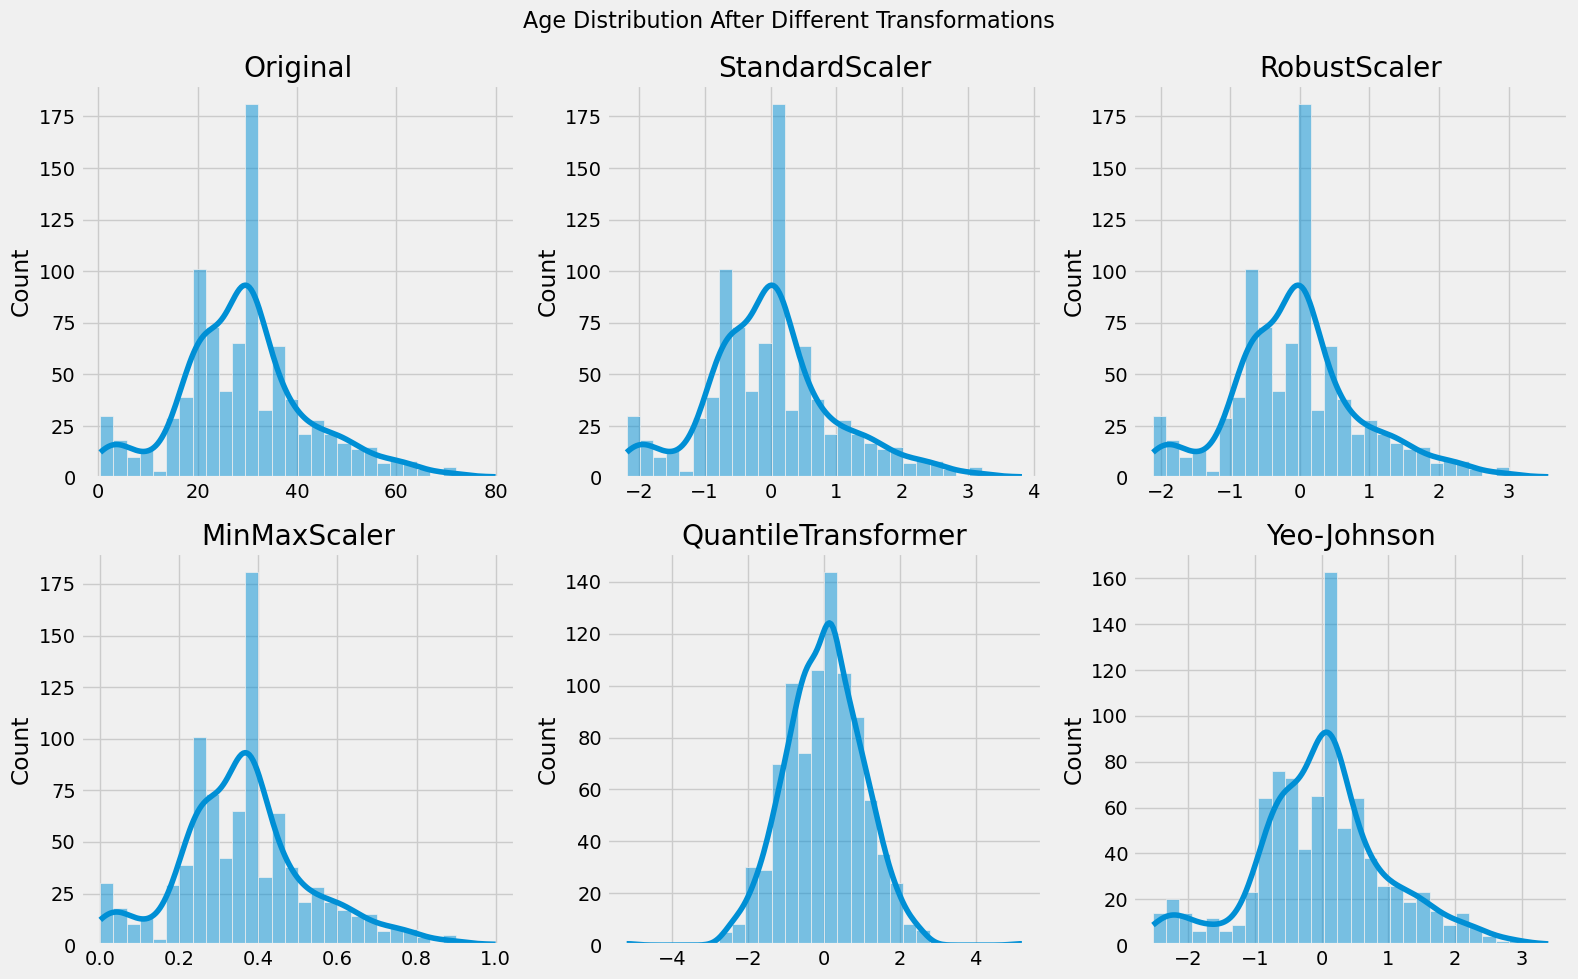

In [90]:
fig, axes = plt.subplots(
    2,
    3,
    figsize=(16, 10),
)

axes = axes.ravel()

for axis, (name, values) in zip(axes, transformations.items()):

    sns.histplot(
        values,
        bins=30,
        kde=True,
        ax=axis,
    )

    axis.set_title(name)

plt.suptitle(
    'Age Distribution After Different Transformations',
    fontsize=16,
)

plt.tight_layout()

### Observations

Distribution transformations had much smaller impact than the missing value imputation strategy.

StandardScaler and PowerTransformer produced identical validation results, while QuantileTransformer and MinMaxScaler slightly reduced cross-validation performance.

This suggests that the primary limitation of the Age feature was the quality of the imputed values rather than its distribution.

Therefore, Title-based imputation followed by StandardScaler was selected as the final preprocessing strategy.

| Experiment          |         CV |        STD | Holdout |          LB | Decision   |
| ------------------- | ---------: | ---------: | ------: | ----------: | ---------- |
| Mean imputation     |     0.8315 |     0.0222 |  0.8380 |     0.76076 | ❌          |
| Median imputation   |     0.8315 |     0.0222 |  0.8436 |     0.76794 | Good       |
| TitleMedianImputer  | **0.8343** | **0.0201** |  0.8380 | **0.77272** | ⭐ Selected |
| QuantileTransformer |     0.8287 |     0.0186 |  0.8436 |           — | ❌          |
| PowerTransformer    |     0.8343 |     0.0201 |  0.8380 |           — | ≈ Standard |
| StandardScaler      | **0.8343** | **0.0201** |  0.8380 | **0.77272** | ⭐ Final    |
